<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/ESAA_YB_WEEK11_transcription1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

파이썬 머신러닝 완벽가이드 ch5. 9-11 pg. 362~398

# **09. 회귀 실습 - 자전거 대여 수요 예측**

- datetime : hourly date + timestamp
- season : 1 = 봄, 2 = 여름, 3 = 가을, 4 = 겨울
- holiday : 1 = 토 ,일요일의 주말을 제외한 국경일 등의 휴일, 0 = 휴일이 아닌 날
- workingday : 1 = 토, 일요일의 주말 및 휴일이 아닌 주중, 0 = 주말 및 휴일
- weather :

  • 1=맑음,약간 구름 낀 흐림

  • 2 = 안개, 안개 + 흐림

  • 3 = 가벼운 눈, 가벼운비 + 천둥

  • 4 = 심한 눈/비, 천둥/번개
- temp : 온도 (섭씨)
- atemp : 체감온도 (섭씨)
- humidity : 상대습도
- windspeed : 풍속
- casual : 사전에 등록되지 않는 사용자가 대여한 횟수
- registered : 사전에 등록된 사용자가 대여한 횟수
- count : 대여 횟수

## **데이터 클렌징 및 가공과 데이터 시각화**

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore', category= RuntimeWarning)

bike_df= pd.read_csv('./bike_train.csv')
print(bike_df)
bike_df.head()

                  datetime  season  holiday  workingday  weather   temp  \
0      2011-01-01 00:00:00       1        0           0        1   9.84   
1      2011-01-01 01:00:00       1        0           0        1   9.02   
2      2011-01-01 02:00:00       1        0           0        1   9.02   
3      2011-01-01 03:00:00       1        0           0        1   9.84   
4      2011-01-01 04:00:00       1        0           0        1   9.84   
...                    ...     ...      ...         ...      ...    ...   
10881  2012-12-19 19:00:00       4        0           1        1  15.58   
10882  2012-12-19 20:00:00       4        0           1        1  14.76   
10883  2012-12-19 21:00:00       4        0           1        1  13.94   
10884  2012-12-19 22:00:00       4        0           1        1  13.94   
10885  2012-12-19 23:00:00       4        0           1        1  13.12   

        atemp  humidity  windspeed  casual  registered  count  
0      14.395        81     0.0000 

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


10886개의 레코드와 12개의 칼럼으로 구성됨

In [5]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
# 문자열을 datetime 타입으로 변경
bike_df['datetime']= bike_df.datetime.apply(pd.to_datetime)

# datetime 타입에서 년, 월, 일, 시간 추출
bike_df['year']= bike_df.datetime.apply(lambda x : x.year)
bike_df['month']= bike_df.datetime.apply(lambda x : x.month)
bike_df['day']= bike_df.datetime.apply(lambda x : x.day)
bike_df['hour']= bike_df.datetime.apply(lambda x : x.hour)
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2


새롭게 year, month, day, hour 칼럼이 추가됨

In [7]:
# datetime 칼럼 삭제 & 상관도가 높아 예측을 저해할 우려가 있는 casual과 registered 칼럼 삭제
drop_columns = ['datetime', 'casual', 'registered']
bike_df.drop(drop_columns, axis=1, inplace=True)

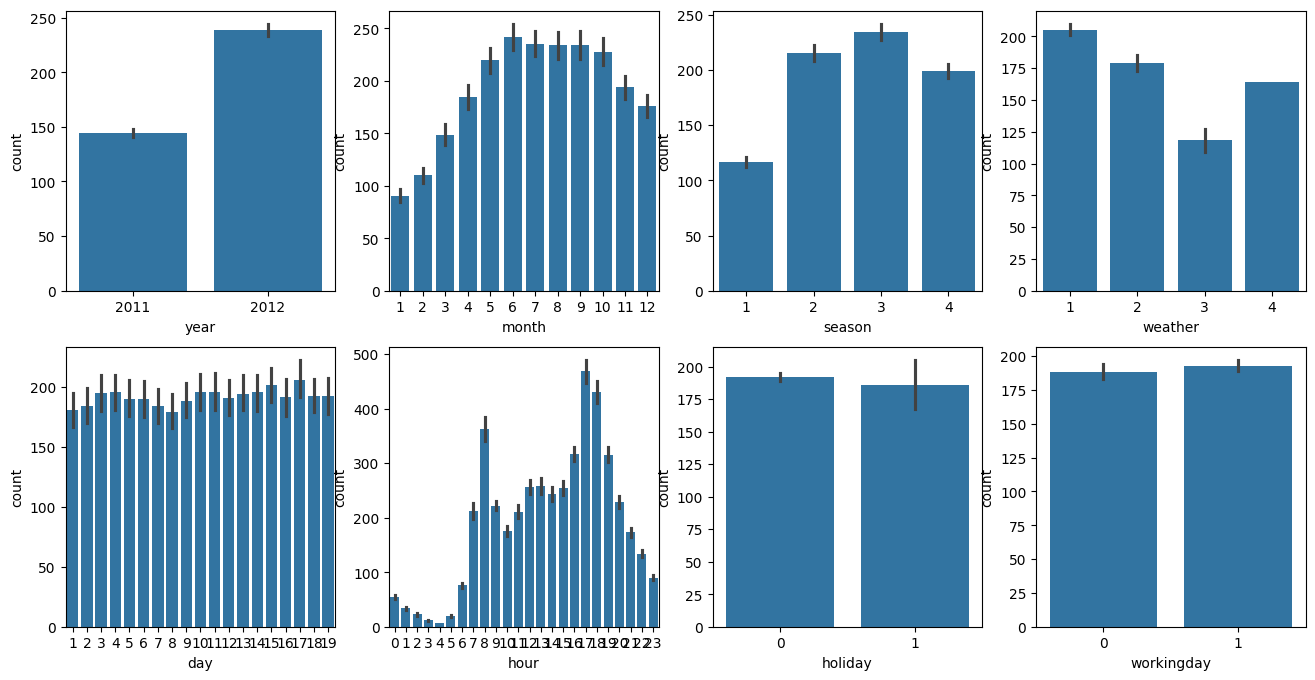

In [8]:
fig, axs= plt.subplots(figsize=(16,8), ncols=4, nrows=2)
cat_features= ['year', 'month', 'season','weather','day','hour','holiday','workingday']

#cat_features에 있는 모든 칼럼별로 개별 칼럼값에 따른 count의 합을 barplot으로 시각화
for i, feature in enumerate(cat_features):
    row= int(i/4)
    col= i%4
    # 시본의 barplot을 이용해 컬럼값에 따른 count의 합을 표현
    sns.barplot(x=feature, y='count', data=bike_df, ax=axs[row][col])

- year(년도)별 count를 보면 2012년이 2011년보다 상대적으로 높다
- month(월별) 횟수는 1,2,3월 낮고 6,7,8,9월 높다
- season(계절): 봄, 겨울이 낮고 여름, 가을이 높다
- weather(날씨)는 눈 또는 비가 있는 경우 낮고, 맑거나 안개있는 경우 높다
- hout(시간)은 출퇴근 시간이 높다
- day(일자)간 차이가 적다
- holiday(휴일)과 workingday(주중) 중에는 주중(holiday=0, workingday=1)인 경우 약간 높다

In [9]:
from sklearn.metrics import mean_squared_error, mean_squared_log_error, mean_absolute_error

# log 값 변환 시 NaN 등의 이슈로 log()가 아닌 log1p()를 이용해 RMSLE 계산
def rmsle(y, pred):
    log_y= np.log1p(y)
    log_pred = np.log1p(pred)
    squared_error= (log_y-log_pred)**2
    rmsle= np.sqrt(np.mean(squared_error))
    return rmsle

# 사이킷런의 mean_square_error()를 이용해 RMSE 계산
def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

# MAE, RMSE, RMSLE를 모두 계산
def evaluate_regr(y, pred):
    rmsle_val= rmsle(y, pred)
    rmse_val = rmse(y, pred)
    # MAE는 사이킷런의 mean_absolute_error()로 계산
    mae_val= mean_absolute_error(y, pred)
    print('RMSLE: {0:.3f}, RMSE: {1:.3f}, MAE: {2:.3f}'.format(rmsle_val, rmse_val, mae_val))

rmsle() 함수를 만들 때 한 가지 주의해야 할 점이 있다.

rmsle를 구할 때 넘파이의 log() 함수를 이용하거나 사이킷런의 mean_squared_log_error()를 이용할 수도 있지만 데이터 값의 크기에 따라 오버플로/언더플로(overflow/underflow) 오류가 발생하기 쉽다.

예를 들어 rmsle()를 다음과 같이 정의했을 때 쉽게 오류가 발생할 수 있다.

In [10]:
#다음과 같은 rmsle구현은 오버플로나 언더플로 오류를 발생하기 쉽습니다
def rmsle(y, pred):
    msle= mean_squared_log_error(y, pred)
    mse= np.mean(msle)
    rmsle= np.sqrt(mse)
    return rmsle

## **로그 변환, 피처 인코딩과 모델 학습/예측/평가**

In [11]:
# 사이킷런의 LinearRegression 객체를 이용해 회귀 예측
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso

y_target= bike_df['count']
X_features= bike_df.drop(['count'], axis=1, inplace=False)
X_train, X_test, y_train, y_test= train_test_split(X_features, y_target, test_size=0.3, random_state=0)

lr_reg= LinearRegression()
lr_reg.fit(X_train, y_train)
pred= lr_reg.predict(X_test)
pred = np.clip(pred, 0, None)

evaluate_regr(y_test, pred)

RMSLE: 1.284, RMSE: 140.186, MAE: 104.193


In [12]:
def get_top_error_data(y_test, pred, n_tops= 5):
    # DataFrame의 칼럼으로 실제 대여 횟수(count)와 예측값을 서로 비교할 수 있도록 생성
    result_df= pd.DataFrame(y_test.values, columns=['real_count'])
    result_df['predicted_count']= np.round(pred)
    result_df['diff']= np.abs(result_df['real_count']- result_df['predicted_count'])

# 예측값과 실제 값이 가장 큰 데이터 순으로 출력
    print(result_df.sort_values('diff', ascending= False)[:n_tops])

get_top_error_data(y_test, pred, n_tops= 5)

      real_count  predicted_count   diff
1618         890            322.0  568.0
966          884            327.0  557.0
3151         798            241.0  557.0
412          745            194.0  551.0
2277         813            267.0  546.0


가장 큰 상위 5위 오류 값은 546~568로 실제 값을 감안하면 예측 오류가 꽤 크다. 이렇게 큰 예측 오류가 발생할 경우 가장 먼저 살펴볼 것은 **Target 값의 분포가 왜곡된 형태를 이루고 있는지 확인**하는 것이다.

<Axes: >

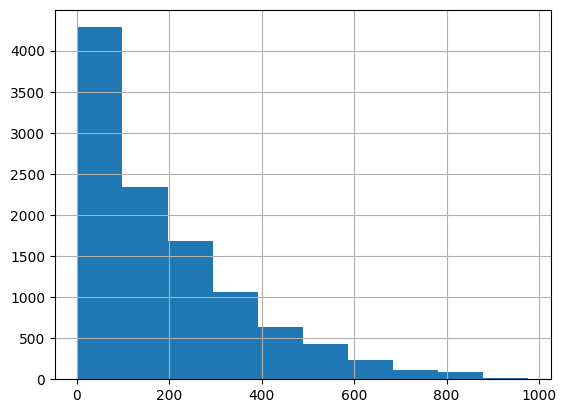

In [13]:
y_target.hist()

count 칼럼이 0~200 사이에 왜곡됨

<Axes: >

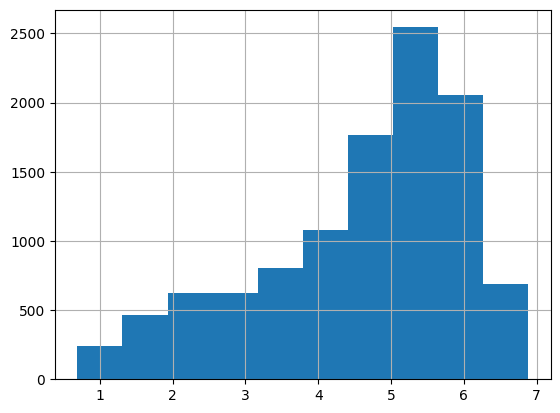

In [15]:
# 로그 적용하여 변환 -> 넘파이의 log1p() 이용
y_log_transform= np.log1p(y_target)
y_log_transform.hist()

In [16]:
# 타깃 칼럼인 count값을 log1p로 로그 변환
y_target_log= np.log1p(y_target)

#로그 변환된 y_target_log를 반영해 학습/ 테스트 데이터 세트 분할
X_train, X_test, y_train, y_test= train_test_split(X_features, y_target_log, test_size=0.3, random_state=0)

lr_reg= LinearRegression()
lr_reg.fit(X_train, y_train)
pred= lr_reg.predict(X_test)

#테스트 데이터 세트의 Target값은 로그 변환됐으므로 다시 expm1을 이용해 원래 스케일로 변환
y_test_exp= np.expm1(y_test)

#예측값 역시 로그 변환된 타깃 기반으로 학습돼 예측됐으므로 다시 expm1로 스케일 변환
pred_exp= np.expm1(pred)

evaluate_regr(y_test_exp, pred_exp)

RMSLE: 1.017, RMSE: 162.594, MAE: 109.286


RMSLE 오류는 줄어들었지만, RMSE는 오히려 더 늘어났다. 이번에는 개별 피처들의 인코딩을 적용해 보자.

먼저 각 피처의 회귀 계숫값을 시각화

<Axes: ylabel='None'>

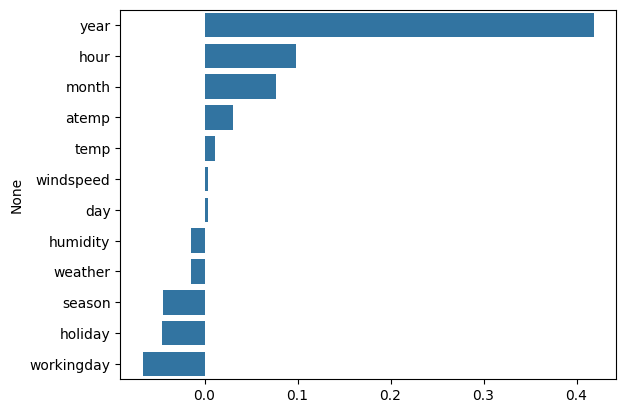

In [17]:
coef= pd.Series(lr_reg.coef_, index=X_features.columns)
coef_sort= coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

In [18]:
#'year', 'month', 'day', 'hour'등의 피처들을 One Hot Encoding
X_features_ohe= pd.get_dummies(X_features, columns= ['year', 'month', 'day', 'hour', 'holiday','workingday','season','weather'])

In [19]:
#원-핫 인코딩이 적용된 피처 데이터 세트 기반으로 학습/예측 데이터 분할
X_train, X_test, y_train, y_test= train_test_split(X_features_ohe, y_target_log, test_size=0.3, random_state=0)

#모델과 학습/ 테스트 데이터 세트를 입력하면 성능 평가 수치를 반환
def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1= False):
    model.fit(X_train, y_train)
    pred= model.predict(X_test)
    if is_expm1:
        y_test= np.expm1(pred)
    print('###', model.__class__.__name__, '###')
    evaluate_regr(y_test, pred)
# end of function get_model_predict

# 모델별로 평가 수행
lr_reg=LinearRegression()
ridge_reg= Ridge(alpha=10)
lasso_reg= Lasso(alpha=0.01)

for model in [lr_reg, ridge_reg, lasso_reg]:
    get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1= True)

### LinearRegression ###
RMSLE: 3.094, RMSE: 232.874, MAE: 173.472
### Ridge ###
RMSLE: 3.085, RMSE: 227.403, MAE: 170.014
### Lasso ###
RMSLE: 3.049, RMSE: 202.030, MAE: 154.963


<Axes: ylabel='None'>

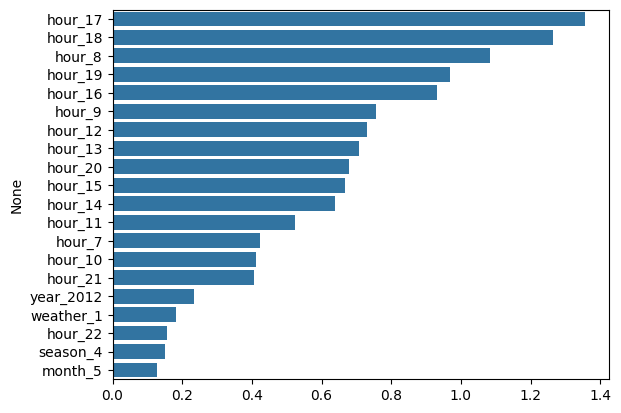

In [21]:
# 원-핫 인코딩으로 피처가 늘어났으므로 회귀 계수 상위 20개 피처 추출
coef= pd.Series(lr_reg.coef_, index=X_features_ohe.columns)
coef_sort = coef.sort_values(ascending= False)[:20]
sns.barplot(x=coef_sort.values, y= coef_sort.index)

원-핫 인코딩을 통해서 피처들의 영향도가 달라졌고, 모델의 성능도 향상되었다. 반드시 그런 것은 아니지만 선형 회귀의 경우 중요 카테고리성 피처들을 원-핫 인코딩으로 변환하는 것은 성능에 중요한 영향을 미칠 수 있다.

In [22]:
# 회귀 트리를 이용해 회귀 예측 수행
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 랜덤 포레스트, GBM, XGBoost, LightGBM model별로 평가 수행
rf_reg= RandomForestRegressor(n_estimators=500)
gbm_reg= GradientBoostingRegressor(n_estimators=500)
xgb_reg= XGBRegressor(n_estimators=500)
lgbm_reg= LGBMRegressor(n_estimators=500)

for model in [rf_reg, gbm_reg, xgb_reg, lgbm_reg]:
    # XGBoost의 경우 DataFrame이 입력될 경우 버전에 따라 오류 발생 가능. ndarray로 변환
    get_model_predict(model, X_train.values, X_test.values, y_train.values, y_test.values, is_expm1=True)

### RandomForestRegressor ###
RMSLE: 3.122, RMSE: 248.151, MAE: 182.662
### GradientBoostingRegressor ###
RMSLE: 3.112, RMSE: 244.127, MAE: 180.098
### XGBRegressor ###
RMSLE: 3.121, RMSE: 255.537, MAE: 185.473
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 348
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 72
[LightGBM] [Info] Start training from score 4.582043
### LGBMRegressor ###
RMSLE: 3.120, RMSE: 253.320, MAE: 184.745


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


앞의 선형 회귀 모델보다 회귀 예측 성능이 개선됨

but 이것이 회귀 트리가 선형 회귀보다 더 나은 성능을 가진다는 의미는 아니며 데이터 세트의 유형에 따라 얼마든지 결과는 달라질 수 있다.

# **10. 회귀 실습 - 캐글 주택 가격: 고급 회귀 기법**

79개의 변수로 구성된 이 데이터는 미국 아이오와 주의 에임스(Ames) 지방의 주택 가격 정보를 갖고 있음

가격이 비싼 주택일수록 예측 결과 오류가 전체 오류에 미치는 비중이 높으므로 이것을 상쇄하기 위해 오류 값을 로그 변환한 RMSLE를 이용

## **데이터 사전 처리 (Preprocessing)**

In [25]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as pit
%matplotlib inline

house_df_org = pd.read_csv('./house_price.csv')
house_df = house_df_org.copy()
house_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


Target 값은 맨 마지막 칼럼인 SalePrice

In [26]:
print('데이터 세트의 Shape:', house_df.shape)
print('\n전체 피처의 type \n', house_df.dtypes.value_counts())
isnull_series= house_df.isnull().sum()
print('\nNUll 칼럼과 그 건수:\n', isnull_series[isnull_series>0].sort_values(ascending=False)) # 내림차순

데이터 세트의 Shape: (1460, 81)

전체 피처의 type 
 object     43
int64      35
float64     3
Name: count, dtype: int64

NUll 칼럼과 그 건수:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


- 1460개의 레코드와 81개의 피처로 구성돼 있으며, 피처의 타입은 숫자형은 물론 문자형도 많이 있다
- Target을 제외한 80개의 피처 중 43개가 문자형, 나머지가 숫자형
- 데이터 양에 비해 Null 값이 많은 피처도 있음

-> Null 값이 너무 많은 피처는 드롭할 것

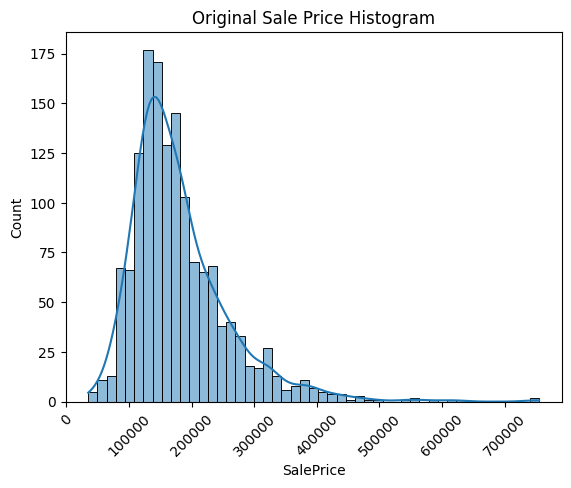

In [27]:
# 회귀 모델 적용 전, 타깃 값이 분포도가 정규 분포인지 확인
plt.title('Original Sale Price Histogram')
plt.xticks(rotation=45)
sns.histplot(house_df['SalePrice'], kde=True)
plt.show()

정규 분포가 아닌 결괏값을 정규 분포 형태로 변환하기 위해 로그 변환(Log Transformation)을 적용

먼저 넘파이의 log1p()를 이용해 로그 변환한 결괏값을 기반으로 학습한 뒤, 예측 시에는 다시 결괏값을 expm1()으로 추후에 환원하면 됨

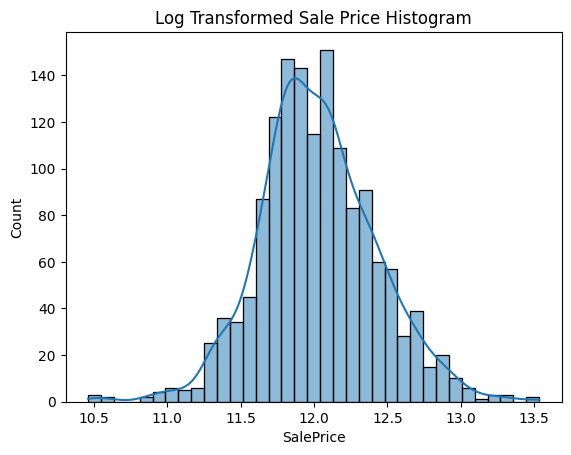

In [28]:
# 결괏값을 로그 변환하고 다시 분포도 살펴보기
plt.title('Log Transformed Sale Price Histogram')
log_SalePrice= np.log1p(house_df['SalePrice'])
sns.histplot(log_SalePrice, kde=True)
plt.show()

SalePrice를 로그 변환해 정규 분포 형태로 결괏값이 분포함을 확인할 수 있다.
- SalePrice를 로그 변환한 뒤 DataFrame에 반영
- Null 값이 많은 피처인 PoolQC, MiscFeature, Alley, Fence, FireplaceQu는 삭제
- Id 도 단순 식별자이므로 삭제
- LotFrontage는 Null이 259개로 비교적 많으나 평균값으로 대체
- 나머지 Null 피처는 Null 값이 많지 않으므로 숫자형의 경우 평균값으로 대체

In [29]:
# SalePrice 로그 변환
original_SalePrice = house_df['SalePrice']
house_df['SalePrice'] = np.log1p(house_df['SalePrice'])

#Null이 너무 많은 칼럼과 불필요한 칼럼 삭제
house_df.drop(['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu'], axis=1, inplace=True)

#드롭하지 않는 숫자형 Null 칼럼은 평균값으로 대체
numerical_cols = house_df.select_dtypes(include=np.number).columns
house_df[numerical_cols] = house_df[numerical_cols].fillna(house_df[numerical_cols].mean())

#Null 값이 있는 피처명과 타입을 추출
null_column_count= house_df.isnull().sum()[house_df.isnull().sum()>0]
print('## Null 피처의 Type:\n', house_df.dtypes[null_column_count.index])

## Null 피처의 Type:
 MasVnrType      object
BsmtQual        object
BsmtCond        object
BsmtExposure    object
BsmtFinType1    object
BsmtFinType2    object
Electrical      object
GarageType      object
GarageFinish    object
GarageQual      object
GarageCond      object
dtype: object


문자형 피처는 모두 원-핫 인코딩으로 변환
- 판다스의 get_dummies() 이용

-> get_dummies()는 자동으로 문자열 피처를 원-핫 인코딩으로 변환하면서 Null 값은 이제 문자형 피처를 제외하고는 Null 값이 없다

In [30]:
print('get_dummies() 수행 전 데이터 shape:', house_df.shape)
house_df_ohe= pd.get_dummies(house_df)
print('get_dummies() 수행 후 데이터 shape:', house_df_ohe.shape)

null_column_count= house_df_ohe.isnull().sum()[house_df_ohe.isnull().sum()>0]
print('## Null 피처의 Type: \n', house_df_ohe.dtypes[null_column_count.index])

get_dummies() 수행 전 데이터 shape: (1460, 75)
get_dummies() 수행 후 데이터 shape: (1460, 270)
## Null 피처의 Type: 
 Series([], dtype: object)


원-핫 인코딩 후 피처가 75개에서 2기개로 증가했다. 그리고 Null 값을 가진 피처는 이제 존재하지 않는다.

## **선형 회귀 모델 학습/예측/평가**

In [31]:
def get_rmse(model):
    pred= model.predict(X_test)
    mse= mean_squared_error(y_test, pred)
    rmse= np.sqrt(mse)
    print(model.__class__.__name__, '로그 변환된 RMSE:', np.round(rmse,3))
    return rmse

def get_rmses(models):
    rmses= [ ]
    for model in models:
        rmse= get_rmse(model)
        rmses.append(rmse)
    return rmses

get_rmse(model)은 단일 모델의 RMSE 값을, getjmises(models)는 get_rmse()를 이용해 여러 모델의 RMSE 값을 반환한다.

In [32]:
# 선형 회귀 모델을 학습하고 예측, 평가
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2,
                                                    random_state=156)

# LinearRegression, Ridge, Lasso 학습, 예측, 평가
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge()
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

LinearRegression 로그 변환된 RMSE: 0.132
Ridge 로그 변환된 RMSE: 0.127
Lasso 로그 변환된 RMSE: 0.176


[np.float64(0.13183184688250701),
 np.float64(0.1274058283626616),
 np.float64(0.17628250556471403)]

라쏘의 경우 회귀 성능이 타 회귀 방식보다 떨어지는 결과가 나옴

-> 최적 하이퍼 파라미터 튜닝이 필요해 보임

In [33]:
def get_top_bottom_coef(model, n=10):
  # coef_ 속성을 기반으로 Series 객체를 생성. index는 칼럼명.
  coef = pd.Series(model.coef_, index=X_features.columns)

  # + 상위 10개, - 하위 10개의 회귀 계수를 추출해 반환.
  coef_high = coef.sort_values(ascending=False).head(n)
  coef_low = coef.sort_values(ascending=False).tail(n)
  return coef_high, coef_low

- 생성한 get_top_bottom_coef(model, n=10 ) 함수를 이용해 모델별 회귀 계수를 시각화
- 시각화를 위한 함수로 visualize_coefficient(models)를 생성

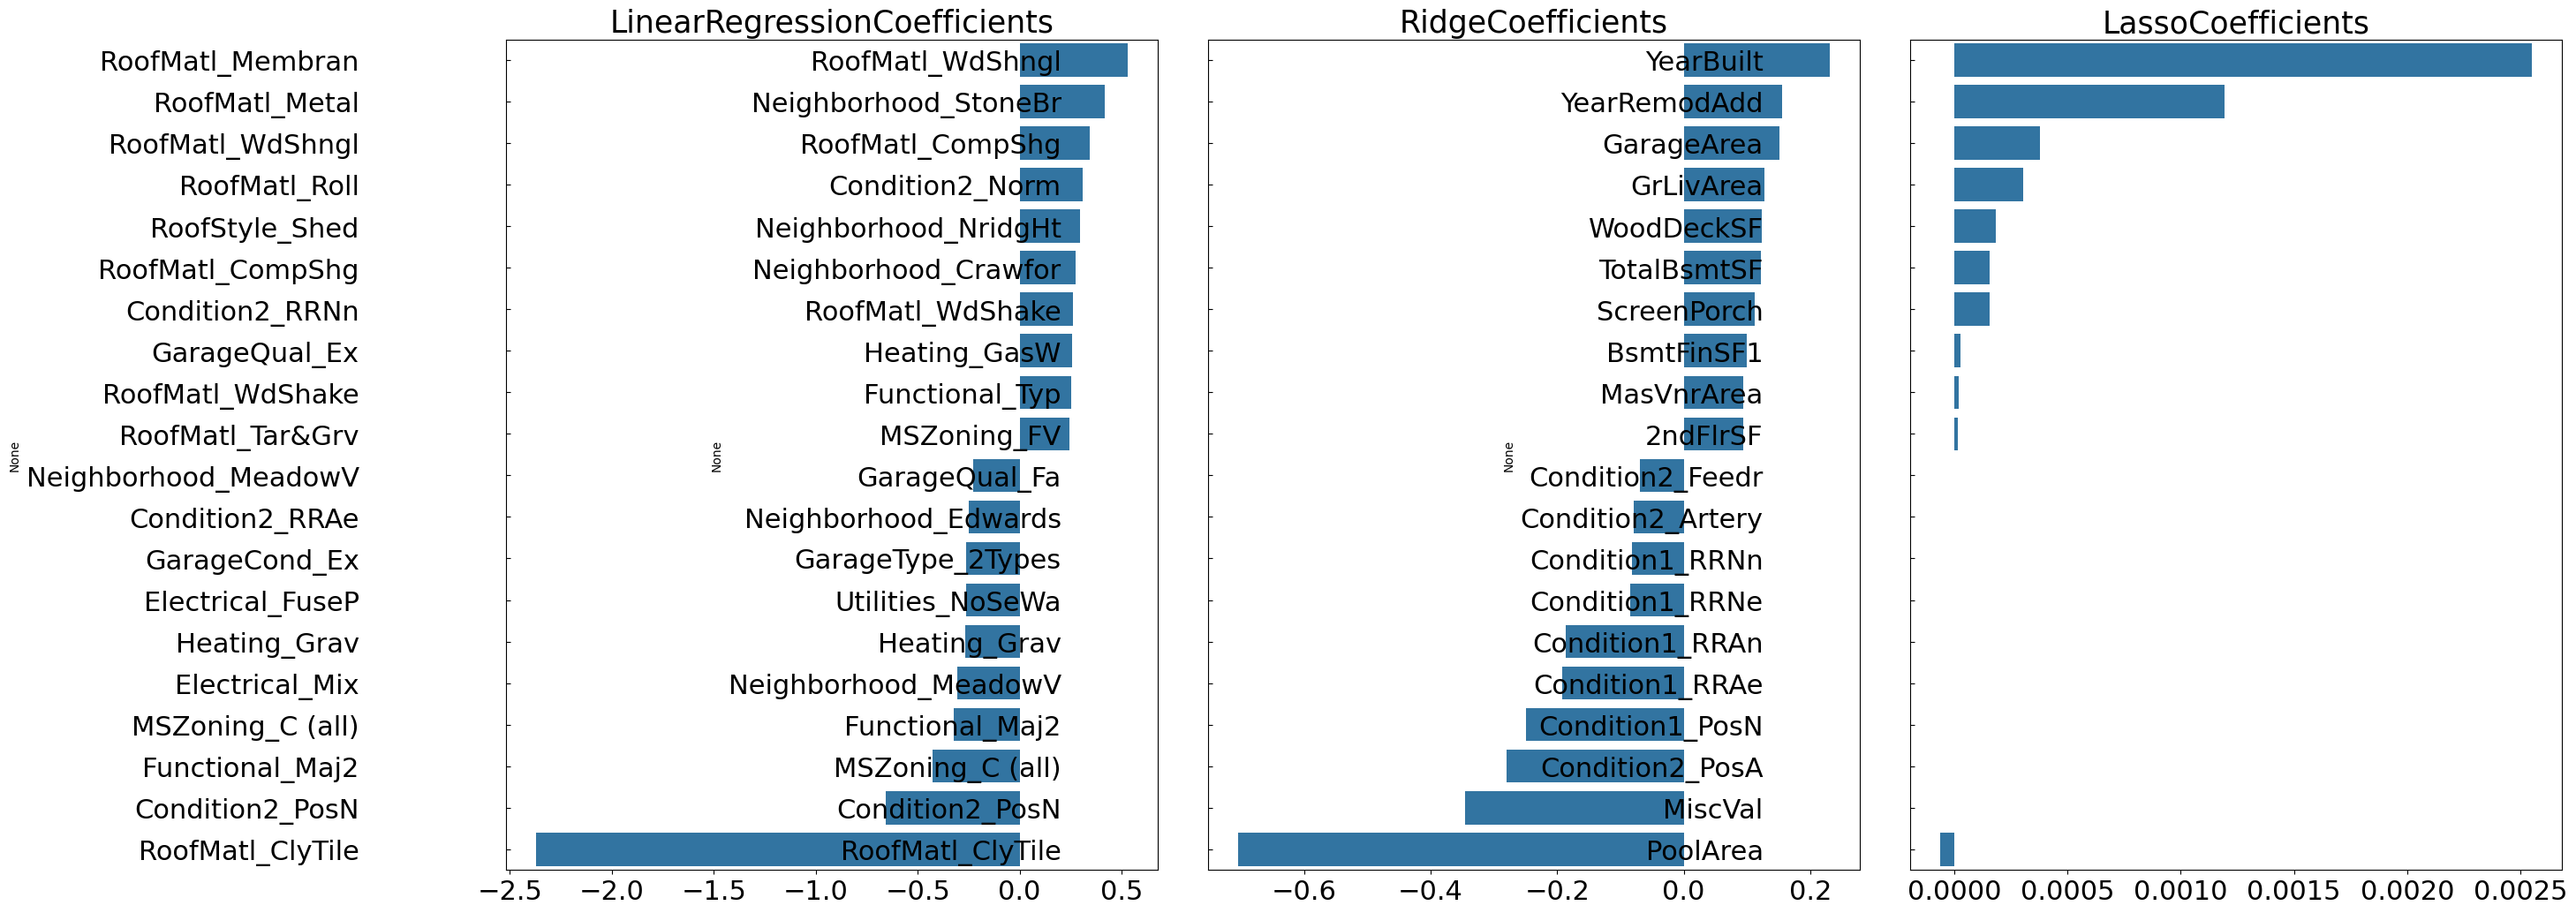

In [34]:
def visualize_coefficient(models):
  # 3개 회귀 모델의 시각화를 위해 3개의 칼럼을 가지는 subplot 생성
  fig, axs = plt.subplots(figsize=(24, 10), nrows=1, ncols=3)
  fig.tight_layout()
  # 입력 인자로 받은 list 객체인 models에서 차례로 model을 추출해 회귀 계수 시각화.
  for i_num, model in enumerate(models):
    # 상위 10개, 하위 10개 회귀 계수를 구하고, 이를 판다스 concat으로 결합
    coef_high, coef_low = get_top_bottom_coef(model)
    coef_concat = pd.concat([coef_high, coef_low])
    # ax subplot에 barchar로 표현. 한 화면에 표현하기 위해 tick label 위치와 font 크기 조정.
    axs[i_num].set_title(model.__class__.__name__+'Coefficients', size=25)
    axs[i_num].tick_params(axis="y", direction="in", pad=120)
    for label in (axs[i_num].get_xticklabels() + axs[i_num].get_yticklabels()):
      label.set_fontsize(22)
    sns.barplot(x=coef_concat.values, y=coef_concat.index, ax=axs[i_num])

# 앞 예제에서 학습한 lr_reg, ridge_reg, lasso_reg 모델의 회귀 계수 시각화.
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

- 모델별 회귀 계수를 보면 OLS 기반의 LinearRegression과 Ridge의 경우는 회귀 계수가 유사한 형태로 분포돼 있음
- 하지만 라쏘(Lasso)는 전체적으로 회귀 계수 값이 매우 작고, 그중에 YearBuilt가 가장 크고 다른 피처의 회귀 계수는 너무 작다.
- 라쏘의 경우 다른 두 개의 모델과 다른 회귀 계
수 형태를 보이고 있다.
- 혹시 학습 데이터의 데이터 분할에 문제가 있어서 그런 것인지, 이번에는 학습과 테스트 데이터 세트를 train_test_split( )으로 분할하지 않고 전체 데이터 세트인 X_features와 yjarget을 5개의 교차 검증 폴드 세트로 분할해 평균 RMSE를 측정해 보자

- 이를 위해 cross_val_score()를 이용

In [35]:
from sklearn.model_selection import cross_val_score

def get_avg_rmse_cv(models):

  for model in models:
    # 분할하지 않고 전체 데이터로 cross_val_score() 수행. 모델별 CV RMSE값과 평균 RMSE 출력
    rmse_list = np.sqrt(-cross_val_score(model, X_features, y_target, scoring="neg_mean_squared_error", cv=5))
    rmse_avg = np.mean(rmse_list)
    print('\n{0} CV RMSE 값 리스트: {1}'.format(model.__class__.__name__, np.round(rmse_list, 3)))
    print('{0} CV 평균 RMSE 값: {1}'.format(model.__class__.__name__, np.round(rmse_avg, 3)))

# 앞 예제에서 학습한 ridge_reg, lasso_reg 모델의 CV RMSE값 출력
models = [ridge_reg, lasso_reg]
get_avg_rmse_cv(models)


Ridge CV RMSE 값 리스트: [0.117 0.154 0.142 0.117 0.189]
Ridge CV 평균 RMSE 값: 0.144

Lasso CV RMSE 값 리스트: [0.161 0.204 0.177 0.181 0.265]
Lasso CV 평균 RMSE 값: 0.198


5개의 폴드 세트로 학습한 후 평가해도 여전히 라쏘의 경우 릿지 모델보다 성능이 떨어진다
- 릿지와 라쏘 모델에 대해서 alpha 하이퍼 파라미터를 변화시키면서 최적 값을 도출해 보자

In [36]:
# 모델별로 최적화 하이퍼 파라미터 작업을 반복적으로 진행하기 위한 별도의 함수 생성
from sklearn.model_selection import GridSearchCV

def print_best_params(model, params):
    grid_model= GridSearchCV(model, param_grid=params, scoring='neg_mean_squared_error', cv=5)
    grid_model.fit(X_features, y_target)
    rmse= np.sqrt(-1*grid_model.best_score_)
    print('{0} 5 CV 시 최적 평균 RMSE 값: {1}, 최적 alpha: {2}'.format(model.__class__.__name__,
                                                               np.round(rmse,4), grid_model.best_params_))

ridge_params= {'alpha': [0.05, 0.1, 1,5,8,10,12,15,20]}
lasso_params= {'alpha': [0.001, 0.005, 0.008, 0.05, 0.03, 0.1,0.5,1,5,10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1418, 최적 alpha: {'alpha': 12}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.142, 최적 alpha: {'alpha': 0.001}


릿지 모델의 경우 alpha가 12에서 최적 평균 RMSE가 0.1418, 라쏘 모델의 경우 alpha가 0.001에서 최적 평균 RMSE가 0.142이다.
- 라쏘 모델의 경우, alpha 값 최적화 이후 예측 성능이 많이 좋아짐

LinearRegression 로그 변환된 RMSE: 0.132
Ridge 로그 변환된 RMSE: 0.124
Lasso 로그 변환된 RMSE: 0.12


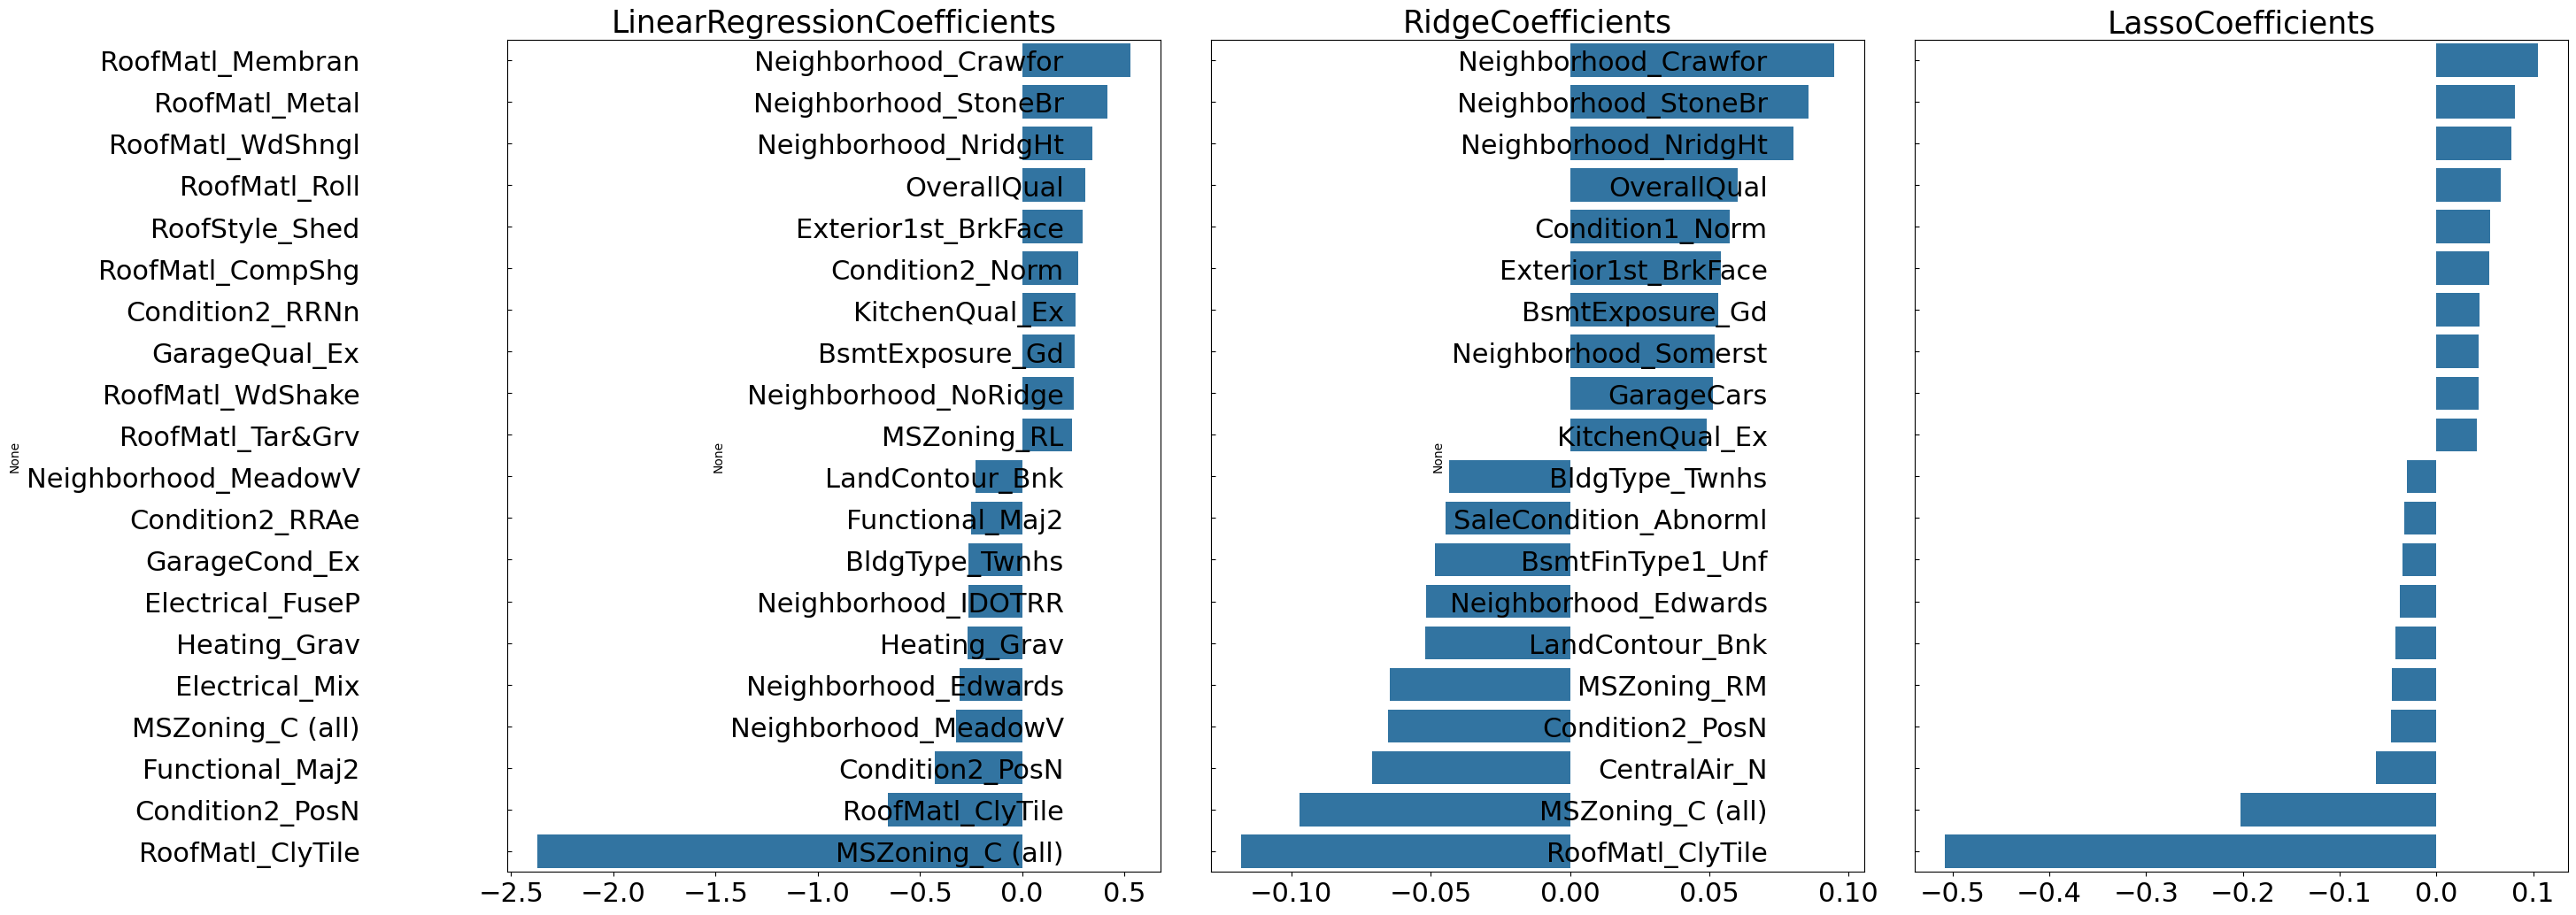

In [37]:
# 앞의 최적화 alpha값으로 학습 데이터로 학습,테스트 데이터로 예측 및 평가 수행
lr_reg= LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg= Ridge(alpha=12)
ridge_reg.fit(X_train, y_train)
lasso_reg= Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

#모든 모델의 RMSE 출력
models= [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

#모든 모델의 회귀 계수 시각화
models= [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

- alpha 값 최적화 후 테스트 데이터 세트의 예측 성능이 더 좋아졌다.
- 모델별 회귀 계수도 많이 달라졌다.
- 기존에는 라쏘 모델의 회귀 계수가 나머지 두 개 모델과 많은 차이가 있었지만, 이번에는 릿지와 라쏘 모델에서 비슷한 피처의 회귀 계수가 높다.
- 다만 라쏘 모델의 경우는 릿지에 비해 동일한 피처라도 회귀 계수의 값이 상당히 작다.

In [38]:
from scipy.stats import skew

#object가 아닌 숫자형 피처의 칼럼 index 객체 추출
features_index= house_df.dtypes[house_df.dtypes != 'object'].index

#house_df에 칼럼 index를 []로 입력하면 해당하는 칼럼 데이터 세트 반환. apply lambda로 skew()호출
skew_features= house_df[features_index].apply(lambda x : skew(x))

#skew(왜곡)정도가 1 이상인 칼럼만 추출
skew_features_top= skew_features[skew_features>1]
print(skew_features_top.sort_values(ascending=False))

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.673661
LotFrontage       2.382499
OpenPorchSF       2.361912
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64


In [39]:
# 추출된 왜곡 정도가 높은 피처를 로그 변환함
house_df[skew_features_top.index]= np.log1p(house_df[skew_features_top.index])

In [40]:
#왜곡 정도가 높은 피처를 로그변환했으므로 다시 원-핫 인코딩을 적용하고 피처/타깃 데이터 세트 생성
house_df_ohe= pd.get_dummies(house_df)
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop(['SalePrice'], axis=1, inplace=False)
X_train, X_test, y_train, y_test= train_test_split(X_features, y_target, test_size=0.2, random_state=156)

#피처를 로그변환한 후 다시 최적 하이퍼 파라미터와 RMSE 출력
ridge_params = { 'alpha':[0.05, 0.1, 1, 5, 8, 10, 12, 15, 20] }
lassojoarams = { 'alpha':[0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10] }
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1275, 최적 alpha: {'alpha': 10}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.1252, 최적 alpha: {'alpha': 0.001}


- 릿지 모델의 경우 최적 alpha값이 12에서 10으로 변경됐고
- 두 모델 모두 피처의 로그 변환 이전과 비교해 릿지의 경우 0.1418에서 0.1275로, 라쏘의 경우 0.142에서 0.1252로, 5 폴드 교차 검증의 평균 RMSE값이 향상됐다.

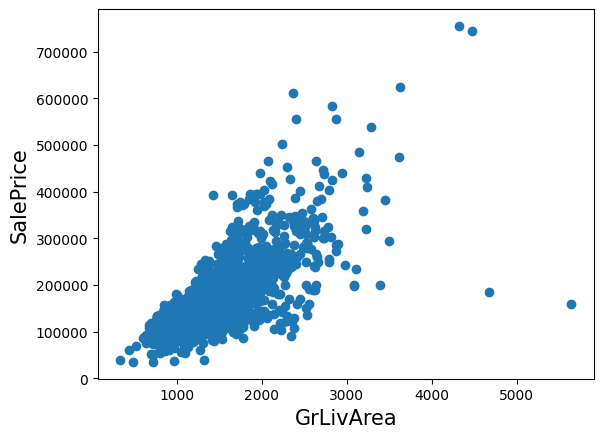

In [41]:
# 주택 가격 데이터가 변환되기 이전의 원본 데이터 세트인 house_df_org에서 GrLivArea와 타깃 값인
# SalePrice의 관계를 시각화
plt.scatter(x= house_df_org['GrLivArea'], y= house_df_org['SalePrice'])
plt.ylabel('SalePrice', fontsize=15)
plt.xlabel('GrLivArea', fontsize=15)
plt.show()

- 일반적으로 주거 공간이 큰 집일수록 가격이 비싸기 때문에 GrLivArea 피처는 SalePrice와 양의 상관도가 매우 높음을 직관적으로 알 수 있다.
- 하지만 위 그림에서 네모로 표시한 2개의 데이터는 일반적인 GrLivArea와 SalePrice 관계에서 너무 어긋나 있다.
- 두 데이터의 GrLivArea가 가장 큰 데도 불구하고 가격은 매우 낮다.
- GrLivArea가 4000평방피트 이상임에도 가격이 500,000달러 이하인 데이터는 모두 이상치로 간주하고 삭제하자.

In [42]:
#GrLivArea와 SalePrice 모두 로그 변환됐으므로 이를 반영한 조건 생성
cond1= house_df_ohe['GrLivArea']> np.log1p(4000)
cond2= house_df_ohe['SalePrice']< np.log1p(500000)
outlier_index= house_df_ohe[cond1& cond2].index

print('이상치 레코드 index: ', outlier_index.values)
print('이상치 삭제 전 house_df_ohe shape:', house_df_ohe.shape)

#DataFrame 의 인덱스를 이용해 이상치 레코드 삭제
house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print('이상치 삭제 후 house_df_ohe shape:', house_df_ohe.shape)

이상치 레코드 index:  [ 523 1298]
이상치 삭제 전 house_df_ohe shape: (1460, 270)
이상치 삭제 후 house_df_ohe shape: (1458, 270)


레코드 인덱스 523, 1298이 대상이며 두 개의 데이터를 삭제해 전체 레코드는 1460개에서 1458개로 줄었다.

In [43]:
# 업데이트된 house_df_ohe를 기반으로 피처 데이터 세트와 타깃 데이터 세트를 다시 생성하고
# 앞에서 정의한 print_best_params( ) 함수를 이용해 릿지와 라쏘 모델의 최적화를 수행
y_target= house_df_ohe['SalePrice']
X_features= house_df_ohe.drop('SalePrice', axis=1, inplace=False)
X_train, X_test, y_train, y_test= train_test_split(X_features, y_target, test_size=0.2, random_state=156)

ridge_params={'alpha': [0.05,0.1,1,5,8,10,12,15,20]}
lasso_params= {'alpha':[0.001,0.005,0.008,0.05,0.03,0.1,0.5,1,5,10]}

print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1125, 최적 alpha: {'alpha': 8}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.1122, 최적 alpha: {'alpha': 0.001}


- 단 두 개의 이상치 데이터만 제거했는데, 예측 수치가 매우 크게 향상됐다.
- 릿지 모델의 경우 최적 alpha 값은 12에서 8로 변했고, 평균 RMSE가 0.1275에서 0.1125로 개선됐다.
- 라쏘 모델의 경우는 평균 RMSE가 0.1252에서 0.1122로 개선됐다.
- 라쏘 모델의 경우 RMSE가 약 0.128
에서 약 0.114로 매우 낮아졌다.


- 웬만큼 하이퍼 파라미터 튜닝을 해도 이 정도의 수치 개선은 어렵다.
- GrLivArea 속성이 회귀 모델에서 차지하는 영향도가 크기에 이 이상치를 개선하는 것이 성능
개선에 큰 의미를 가졌다.

- 이상치가 제거된 데이터 세트를 기반으로 다시 train_test_split()로 분할된 데이터 세트의 RMSE 수치 및 회귀 계수 시각화한 결과

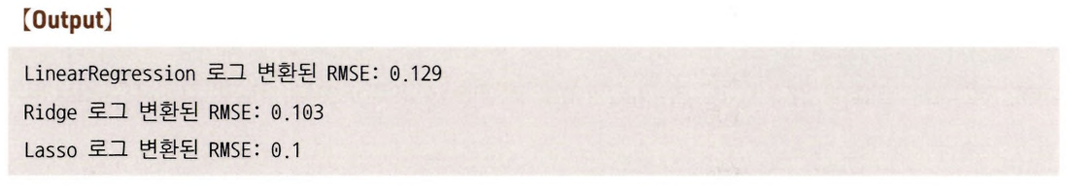

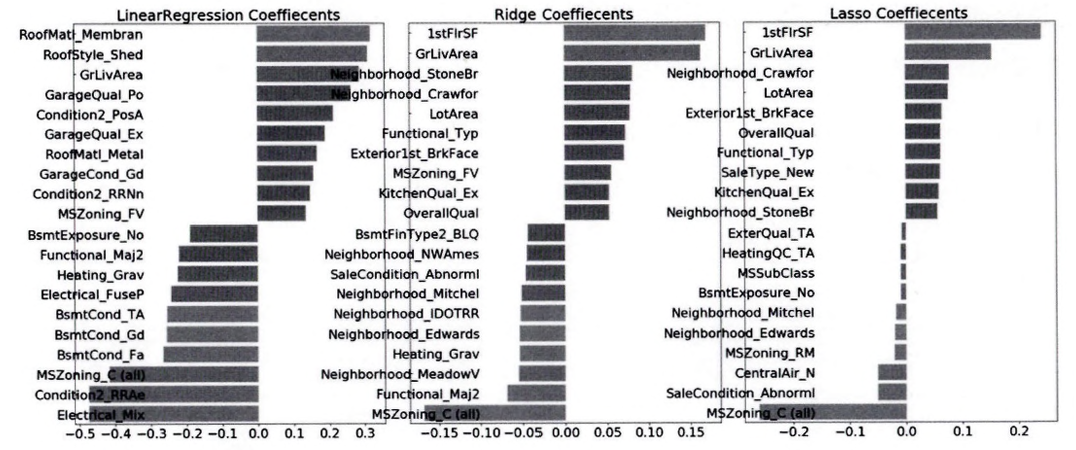

## **회귀 트리 모델 학습/예측/평가**

XGBoost는 XGBRegressor 클래스를,
LightGBM은 LGBMRegressor 클래스를 이용
- XGBoost, LightGBM 모두 수행 시간이 오래
걸릴 수 있는 관계로 다음과 같은 하이퍼 파라미터 설정을 미리 적용한 상태로 5 폴드 세트에 대한 평
균 RMSE 값을 구하겠다.

In [44]:
from xgboost import XGBRegressor

xgb_params={'n_estimators':[1000]}
xgb_reg= XGBRegressor(n_estimators= 1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
print_best_params(xgb_reg, xgb_params)

XGBRegressor 5 CV 시 최적 평균 RMSE 값: 0.1206, 최적 alpha: {'n_estimators': 1000}


XGBoost 회귀 트리를 적용했을 때 5 폴드 세트 평균 RMSE가 약 0.1178

In [45]:
from lightgbm import LGBMRegressor

lgbm_params= {'n_esimators': [1000]}
lgbm_reg = LGBMRegressor(n_esitmators=1000, learning_rate=0.05, num_leaves=4, subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)

print_best_params(lgbm_reg, lgbm_params)

[LightGBM] [Warning] Unknown parameter: n_esimators
[LightGBM] [Warning] Unknown parameter: n_esitmators
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: n_esimators
[LightGBM] [Warning] Unknown parameter: n_esitmators
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3155
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 171
[LightGBM] [Info] Start training from score 12.021352
[LightGBM] [Warning] Unknown parameter: n_esimators
[LightGBM] [Warning] Unknown parameter: n_esitmators
[LightGBM] [Warning] Unknown parameter: n_esimators
[LightGBM] [Warning] Unknown parameter: n_esitmators
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [W

LightGBM 적용 시 5 폴드 세트 평균 RMSE가 약 0.1163

## **회귀 모델의 예측 결과 혼합을 통한 최종 예측**

- 앞서 구한 릿지 모델과 라쏘 모델을 서로 혼합

최종 혼합 모델, 개별 모델의 RMSE 값을 출력하는 get_rmse_pred() 함수를 생성하고 각 모델의 예측값을 계산한 뒤 개별 모델과 최종 혼합 모델의 RMSE를 구한다.

In [46]:
# 릿지 모델과 라쏘 모델 혼합
def get_rmse_pred(preds):
    for key in preds.keys():
        pred_value= preds[key]
        mse= mean_squared_error(y_test, pred_value)
        rmse= np.sqrt(mse)
        print('{0} 모델의 RMSE: {1}'.format(key, rmse))

# 개별 모델의 학습
ridge_reg = Ridge(alpha=8)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

# 개별 모델 예측
ridge_pred = ridge_reg.predict(X_test)
lasso_pred = lasso_reg.predict(X_test)

# 개별 모델 예측값 혼합으로 최종 예측값 도출
pred = 0.4 * ridge_pred + 0.6 * lasso_pred
preds = {'최종 혼합': pred,
         'Ridge': ridge_pred,
         'Lasso':lasso_pred}

# 최종 혼합 모델, 개별 모델의 RMSE 값 출력
get_rmse_pred(preds)

최종 혼합 모델의 RMSE: 0.10006075517615193
Ridge 모델의 RMSE: 0.10340697165289348
Lasso 모델의 RMSE: 0.10024171179335342


최종 혼합 모델의 RMSE가 개별 모델보다 성능 면에서 약간 개선됐다.

In [47]:
# XGBoost와 LightGBM 혼합
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                       colsample_bytree=0.5, subsample= 0.8)

lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4,
                         subsample=0.6, colsample_bytree=0.4, reg_lambda=10, njobs=-1)
xgb_reg.fit(X_train, y_train)
lgbm_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)
lgbm_pred = lgbm_reg.predict(X_test)

pred = 0.5 * xgb_pred + 0.5 * lgbm_pred
preds = {'최종 혼합': pred,'XGBM':xgb_pred,
         'LGBM': lgbm_pred}

get_rmse_pred(preds)

[LightGBM] [Warning] Unknown parameter: njobs
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: njobs
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3174
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 172
[LightGBM] [Info] Start training from score 12.025343
[LightGBM] [Warning] Unknown parameter: njobs
최종 혼합 모델의 RMSE: 0.10215383402419025
XGBM 모델의 RMSE: 0.10761344291735733
LGBM 모델의 RMSE: 0.10363891833477148


XGBoost와 LightGBM의 혼합 모델의 RMSE가 개별 모델의 RMSE보다 조금 향상됐다.

## **스태킹 앙상블 모델을 통한 회귀 예측**

스태킹 모델은 두 종류의 모델이 필요
- 첫 번째는 개별적인 기반 모델
- 두 번째 이 개별 기반 모델의 예측 데이터를 학습 데이터로 만들어서 학습하는 최종 메타 모델


스태킹 모델의 핵심: 여러 개별 모델의 예측 데이터를 각각 스태킹 형태로 결합해 최종 메타 모델의 학습용 피처 데이터 세트와 테스트용 피처 데이터 세트를 만드는 것

- 최종 메타 모델이 학습할 피처 데이터 세트는 원본 학습 피처 세트로 학습한 개별 모델의 예측값을 스태킹 형태로 결합한 것
- 개별 모델을 스태킹 모델로 제공하기 위해 데이터 세트를 생성하기 위한 get_stackingj3ase_datasets() 함수

In [48]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

#개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    #지정된 n_folds값으로 KFold생성
    kf= KFold(n_splits=n_folds, shuffle=False)
    # 추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
    train_fold_pred= np.zeros((X_train_n.shape[0],1))
    test_pred= np.zeros((X_test_n.shape[0], n_folds))
    print(model.__class__.__name__, 'model 시작')

    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        #입력된 학습 데이터에서 기반 모델이 학습/ 예측할 폴드 데이터 세트 추출
        print('\t 폴드 세트:', folder_counter, '시작')
        X_tr= X_train_n[train_index]
        y_tr= y_train_n[train_index]
        X_te= X_train_n[valid_index]

        #폴드세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행
        model.fit(X_tr, y_tr)
        #폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장
        train_fold_pred[valid_index, :]= model.predict(X_te).reshape(-1,1)
        #입력된 원본 테스트 데이터를 폴드 세트 내 학습된 기반 모델에서 예측 후 데이터 저장
        test_pred[:, folder_counter]= model.predict(X_test_n)

    # 폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1, 1)
    # train_fold_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_m은an은 테스트 데이터
    return train_fold_pred, test_pred_mean

- get_stacking_base_datasets()는 인자로 개별 기반 모델, 그리고 원래 사용되는 학습 데이터와 테스트용 피처 데이터를 입력받는다.
- 함수 내에서는 개별 모델이 K-폴드 세트로 설정된 폴드 세트 내부에서 원본의 학습 데이터를 다시 추출해 학습과 예측을 수행한 뒤 그 결과를 저장
- 저장된 예측 데이터는 추후에 메타 모델의 학습 피처 데이터 세트로 이용된다.
- 또한 함수 내에서 폴드 세트 내부 학습 데이터로 학습된 개별 모델이 인자로 입력된 원본 테스트 데이터를 예측한 뒤, 예측 결과를 평균해 테스트 데이터로 생성

In [49]:
# get_stacking_base_datasets()를 모델별로 적용해 메타 모델이 사용할 학습/테스트 피처 데이터 세트 추출
# get_stacking_base_datasets( )는 넘파이 ndarray를 인자로 사용하므로 DataFrame을 넘파이로 변환.
X_train_n = X_train.values
X_test_n = X_test.values
y_train_n = y_train. values

# 각 개별 기반(Base) 모델이 생성한 용/테스트용 데이터 반환.
ridge_train, ridge_test = get_stacking_base_datasets(ridge_reg, X_train_n, y_train_n, X_test_n, 5)
lasso_train, lasso_test = get_stacking_base_datasets(lasso_reg, X_train_n, y_train_n, X_test_n, 5)
xgb_train, xgb_test = get_stacking_base_datasets(xgb_reg, X_train_n, y_train_n, X_test_n, 5)
lgbm_train, lgbm_test = get_stacking_base_datasets(lgbm_reg, X_train_n, y_train_n, X_test_n, 5)

Ridge model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
Lasso model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
XGBRegressor model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
LGBMRegressor model 시작
	 폴드 세트: 0 시작
[LightGBM] [Warning] Unknown parameter: njobs
[LightGBM] [Warning] Unknown parameter: njobs
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2924
[LightGBM] [Info] Number of data points in the train set: 932, number of used features: 156
[LightGBM] [Info] Start training from score 12.035561
[LightGBM] [Warning] Unknown parameter: njobs
[LightGBM] [Warning] Unknown parameter: njobs
	 폴드 세트: 1 시작
[LightGBM] [Warning] Unknown parameter: njobs
[LightGBM] [Warning] Unknown parameter: njobs
[Ligh

In [50]:
#개별 모델이 반환한 학습 및 테스트용 데이터 세트를 스태킹 형태로 결합
Stack_final_X_train= np.concatenate((ridge_train, lasso_train, xgb_train, lgbm_train), axis=1)
Stack_final_X_test= np.concatenate((ridge_test, lasso_test, xgb_test, lgbm_test), axis=1)
#최종 메타  모델은 라쏘모델을 적용
meta_model_lasso= Lasso(alpha=0.0005)

#개별 모델 예측값을 기반으로 새롭게 만들어진 학습/테스트 데이터로 메타모델 예측및 RMSE 측정
meta_model_lasso.fit(Stack_final_X_train, y_train)
final= meta_model_lasso.predict(Stack_final_X_test)
mse= mean_squared_error(y_test, final)
rmse= np.sqrt(mse)
print('스태킹 회귀 모델의 최종 RMSE값은:', rmse)

스태킹 회귀 모델의 최종 RMSE값은: 0.09704503149148055


최종적으로 스태킹 회귀 모델을 적용한 결과, 테스트 데이터 세트에서 RMSE가 약 0.0979로 현재까지 가장 좋은 성능 평가를 보여준다.

스태킹 모델은 분류뿐만 아니라 회귀에서 특히 효과적으로 사용될 수 있는 모델이다.